# 🧮 unitary
**Obtiene y visualiza la matriz unitaria de un circuito cuántico.**

Usa `qiskit.quantum_info.Operator` para extraer la matriz $U \in \mathbb{C}^{2^n \times 2^n}$
correspondiente a cualquier `QuantumCircuit`.

> ⚠️ **Convención Qiskit (little-endian)**: `q[0]` es el bit *menos* significativo.
> La fila/columna $k$ corresponde al estado base $|k\rangle$ leído de derecha a izquierda.
>
> ⚠️ El circuito **no puede tener mediciones** antes de calcular la unitaria.
> Usa `remove_final_measurements()` si es necesario.

## 📦 1. Instalación de dependencias

In [19]:
try:
    import qiskit
    print(f"✅ Qiskit {qiskit.__version__} ya instalado")
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "qiskit", "qiskit-aer", "pylatexenc", "-q"])
    print("✅ Qiskit instalado correctamente")

✅ Qiskit 2.4.1 ya instalado


## 📚 2. Imports

In [20]:
import json
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Operator
from qiskit.circuit.library import (
    RZGate, RYGate, XGate, CXGate, HGate, ZGate, SGate, TGate,
)

print("✅ Imports OK")

✅ Imports OK


## 🔧 3. Helpers: obtener y mostrar la unitaria

### `get_unitary(circuit)`
Devuelve la matriz como `np.ndarray` complejo, eliminando mediciones si existen.

### `print_unitary(U)`
Imprime la matriz en formato tabla, mostrando módulo y fase de cada elemento.

### `plot_unitary(U)`
Grafica la matriz como un heatmap de módulo (amplitud) y otro de fase.

In [21]:
def get_unitary(circuit: QuantumCircuit) -> np.ndarray:
    """
    Extrae la matriz unitaria de un QuantumCircuit.

    - Elimina mediciones finales automáticamente.
    - Retorna np.ndarray de forma (2^n, 2^n) con dtype complex128.
    - Convención Qiskit: q[0] es el bit menos significativo (little-endian).
    """
    qc = circuit.copy()
    qc.remove_final_measurements()
    return Operator(qc).data


def _fmt(z: complex) -> str:
    """Formatea un número complejo como 'modulo∠fase°'."""
    mod   = abs(z)
    phase = math.degrees(math.atan2(z.imag, z.real))
    if mod < 1e-10:
        return "   0         "
    return f"{mod:+.4f}∠{phase:+7.2f}°"


def print_unitary(U: np.ndarray, precision: int = 4) -> None:
    """
    Imprime la unitaria en consola.

    Parámetros
    ----------
    U         : matriz unitaria (output de get_unitary)
    precision : decimales para la parte real/imaginaria
    """
    n = U.shape[0]
    n_qubits = int(math.log2(n))
    labels   = [f"|{i:0{n_qubits}b}⟩" for i in range(n)]

    header = "         " + "  ".join(f"{l:^15}" for l in labels)
    print(header)
    print("─" * len(header))

    for i, row in enumerate(U):
        row_str = "  ".join(_fmt(z) for z in row)
        print(f"{labels[i]}   {row_str}")


def plot_unitary(U: np.ndarray, title: str = "Matriz Unitaria") -> None:
    """
    Visualiza la unitaria con dos heatmaps: módulo y fase.

    - Panel izquierdo : módulo |U_ij|   (colormap viridis, rango [0, 1])
    - Panel derecho   : fase arg(U_ij)  (colormap hsv, rango [-π, π])
    """
    n        = U.shape[0]
    n_qubits = int(math.log2(n))
    labels   = [f"|{i:0{n_qubits}b}⟩" for i in range(n)]

    mod   = np.abs(U)
    phase = np.angle(U)            # radianes en [-π, π]

    fig, axes = plt.subplots(1, 2, figsize=(max(8, n * 1.2), max(4, n * 0.9)))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ── Módulo ───────────────────────────────────────────────────────────────
    im0 = axes[0].imshow(mod, cmap="viridis", vmin=0, vmax=1, aspect="auto")
    axes[0].set_title("Módulo  |U|")
    axes[0].set_xticks(range(n)); axes[0].set_xticklabels(labels, rotation=45, ha="right")
    axes[0].set_yticks(range(n)); axes[0].set_yticklabels(labels)
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    for i in range(n):
        for j in range(n):
            v = mod[i, j]
            if v > 1e-6:
                axes[0].text(j, i, f"{v:.2f}",
                             ha="center", va="center", fontsize=8,
                             color="white" if v < 0.7 else "black")

    # ── Fase ─────────────────────────────────────────────────────────────────
    im1 = axes[1].imshow(phase, cmap="hsv", vmin=-math.pi, vmax=math.pi, aspect="auto")
    axes[1].set_title("Fase  arg(U)  [rad]")
    axes[1].set_xticks(range(n)); axes[1].set_xticklabels(labels, rotation=45, ha="right")
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(labels)
    cbar1 = fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    cbar1.set_ticks([-math.pi, -math.pi/2, 0, math.pi/2, math.pi])
    cbar1.set_ticklabels(["-π", "-π/2", "0", "π/2", "π"])

    for i in range(n):
        for j in range(n):
            if mod[i, j] > 1e-6:
                axes[1].text(j, i, f"{phase[i,j]:.2f}",
                             ha="center", va="center", fontsize=8, color="black")

    plt.tight_layout()
    plt.show()


print("✅ Helpers definidos")

✅ Helpers definidos


In [22]:
single_gates = {
    "H":        lambda qc: qc.h(0),
    "X":        lambda qc: qc.x(0),
    "Z":        lambda qc: qc.z(0),
    "S":        lambda qc: qc.s(0),
    "T":        lambda qc: qc.t(0),
    "Rz(π/4)": lambda qc: qc.rz(math.pi / 4, 0),
    "Ry(π/3)": lambda qc: qc.ry(math.pi / 3, 0),
}

for gate_name, apply in single_gates.items():
    qc = QuantumCircuit(1)
    apply(qc)
    U = get_unitary(qc)
    print(f"── {gate_name} ──────────────────────")
    print(np.round(U, 4))
    print()

── H ──────────────────────
[[ 0.7071+0.j  0.7071+0.j]
 [ 0.7071+0.j -0.7071+0.j]]

── X ──────────────────────
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]

── Z ──────────────────────
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]

── S ──────────────────────
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]

── T ──────────────────────
[[1.    +0.j     0.    +0.j    ]
 [0.    +0.j     0.7071+0.7071j]]

── Rz(π/4) ──────────────────────
[[0.9239-0.3827j 0.    +0.j    ]
 [0.    +0.j     0.9239+0.3827j]]

── Ry(π/3) ──────────────────────
[[ 0.866+0.j -0.5  +0.j]
 [ 0.5  +0.j  0.866+0.j]]



In [23]:
GATE_MAP: dict = {
    "X":    lambda p: XGate(),
    "H":    lambda p: HGate(),
    "Z":    lambda p: ZGate(),
    "S":    lambda p: SGate(),
    "T":    lambda p: TGate(),
    "Rz":   lambda p: RZGate(p),
    "RZ":   lambda p: RZGate(p),
    "Ry":   lambda p: RYGate(p),
    "RY":   lambda p: RYGate(p),
    "CNOT": lambda p: CXGate(),
    "CX":   lambda p: CXGate(),
}


def _resolve_control(c) -> int:
    if isinstance(c, int):
        return c
    if isinstance(c, dict):
        return c["qubit"]
    raise ValueError(f"Formato de control no reconocido: {c!r}")


def parse_json_to_circuit(json_data: dict) -> QuantumCircuit:
    n_qubits   = json_data["qubits"]
    operations = json_data["operations"]
    level      = json_data.get("level", "?")

    qr = QuantumRegister(n_qubits, name="q")
    cr = ClassicalRegister(n_qubits, name="c")
    qc = QuantumCircuit(qr, cr, name=f"nivel{level}")

    for op in operations:
        gate_def  = op["gate"]
        name      = gate_def["name"]
        parameter = gate_def.get("parameter", None)
        controls  = gate_def.get("controls", [])
        target    = gate_def["target"]

        gate = GATE_MAP[name](parameter).to_mutable()
        gate.label = gate_def.get("label", name)

        control_indices = [_resolve_control(c) for c in controls]
        all_qubits      = [qr[c] for c in control_indices] + [qr[target]]
        qc.append(gate, all_qubits)

    qc.measure(qr, cr)
    return qc


print("✅ Parser listo")

✅ Parser listo


### Nivel 1 (4 qubits → matriz 16×16)

In [24]:
with open("nivel6.json", "r") as f:
    data6 = json.load(f)

qc6   = parse_json_to_circuit(data6)
U1 = get_unitary(qc6)

print(f"⚛️  nivel6.json — {U1.shape[0]}×{U1.shape[1]} unitaria")
print("Módulos (valores ~0 truncados a 0):")
print(np.round(U1, 4))
#print(np.where(np.abs(U6) < 1e-8, 0, np.round(np.abs(U6), 4)))

⚛️  nivel6.json — 16×16 unitaria
Módulos (valores ~0 truncados a 0):
[[ 0.6533-0.2706j  0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.6533+0.2706j  0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.6533-0.2706j  0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j     -0.6533-0.2706j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.    +0.j      0.    +0.j      0.6533-0.2706j  0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.6533+0.2706j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.    +0.j      0.    +0.j    ]
 [ 0.6533-0.2706j  0.    +0.j      0.    +0.j      0.    +0.j
   0.    +0.j     -0.6533-0.2706j  0.    +0.j      0.    +0.j
   0.    +0.j      0.    +0.j      0.   

In [40]:
dim=U1.shape[0]
n_qubits = int(np.log2(dim))
qc = QuantumCircuit(n_qubits)

qc.unitary(U1, range(n_qubits))
qc.draw()


┌──────────┐
q_0: ┤0         ├
     │          │
q_1: ┤1         ├
     │  Unitary │
q_2: ┤2         ├
     │          │
q_3: ┤3         ├
     └──────────┘

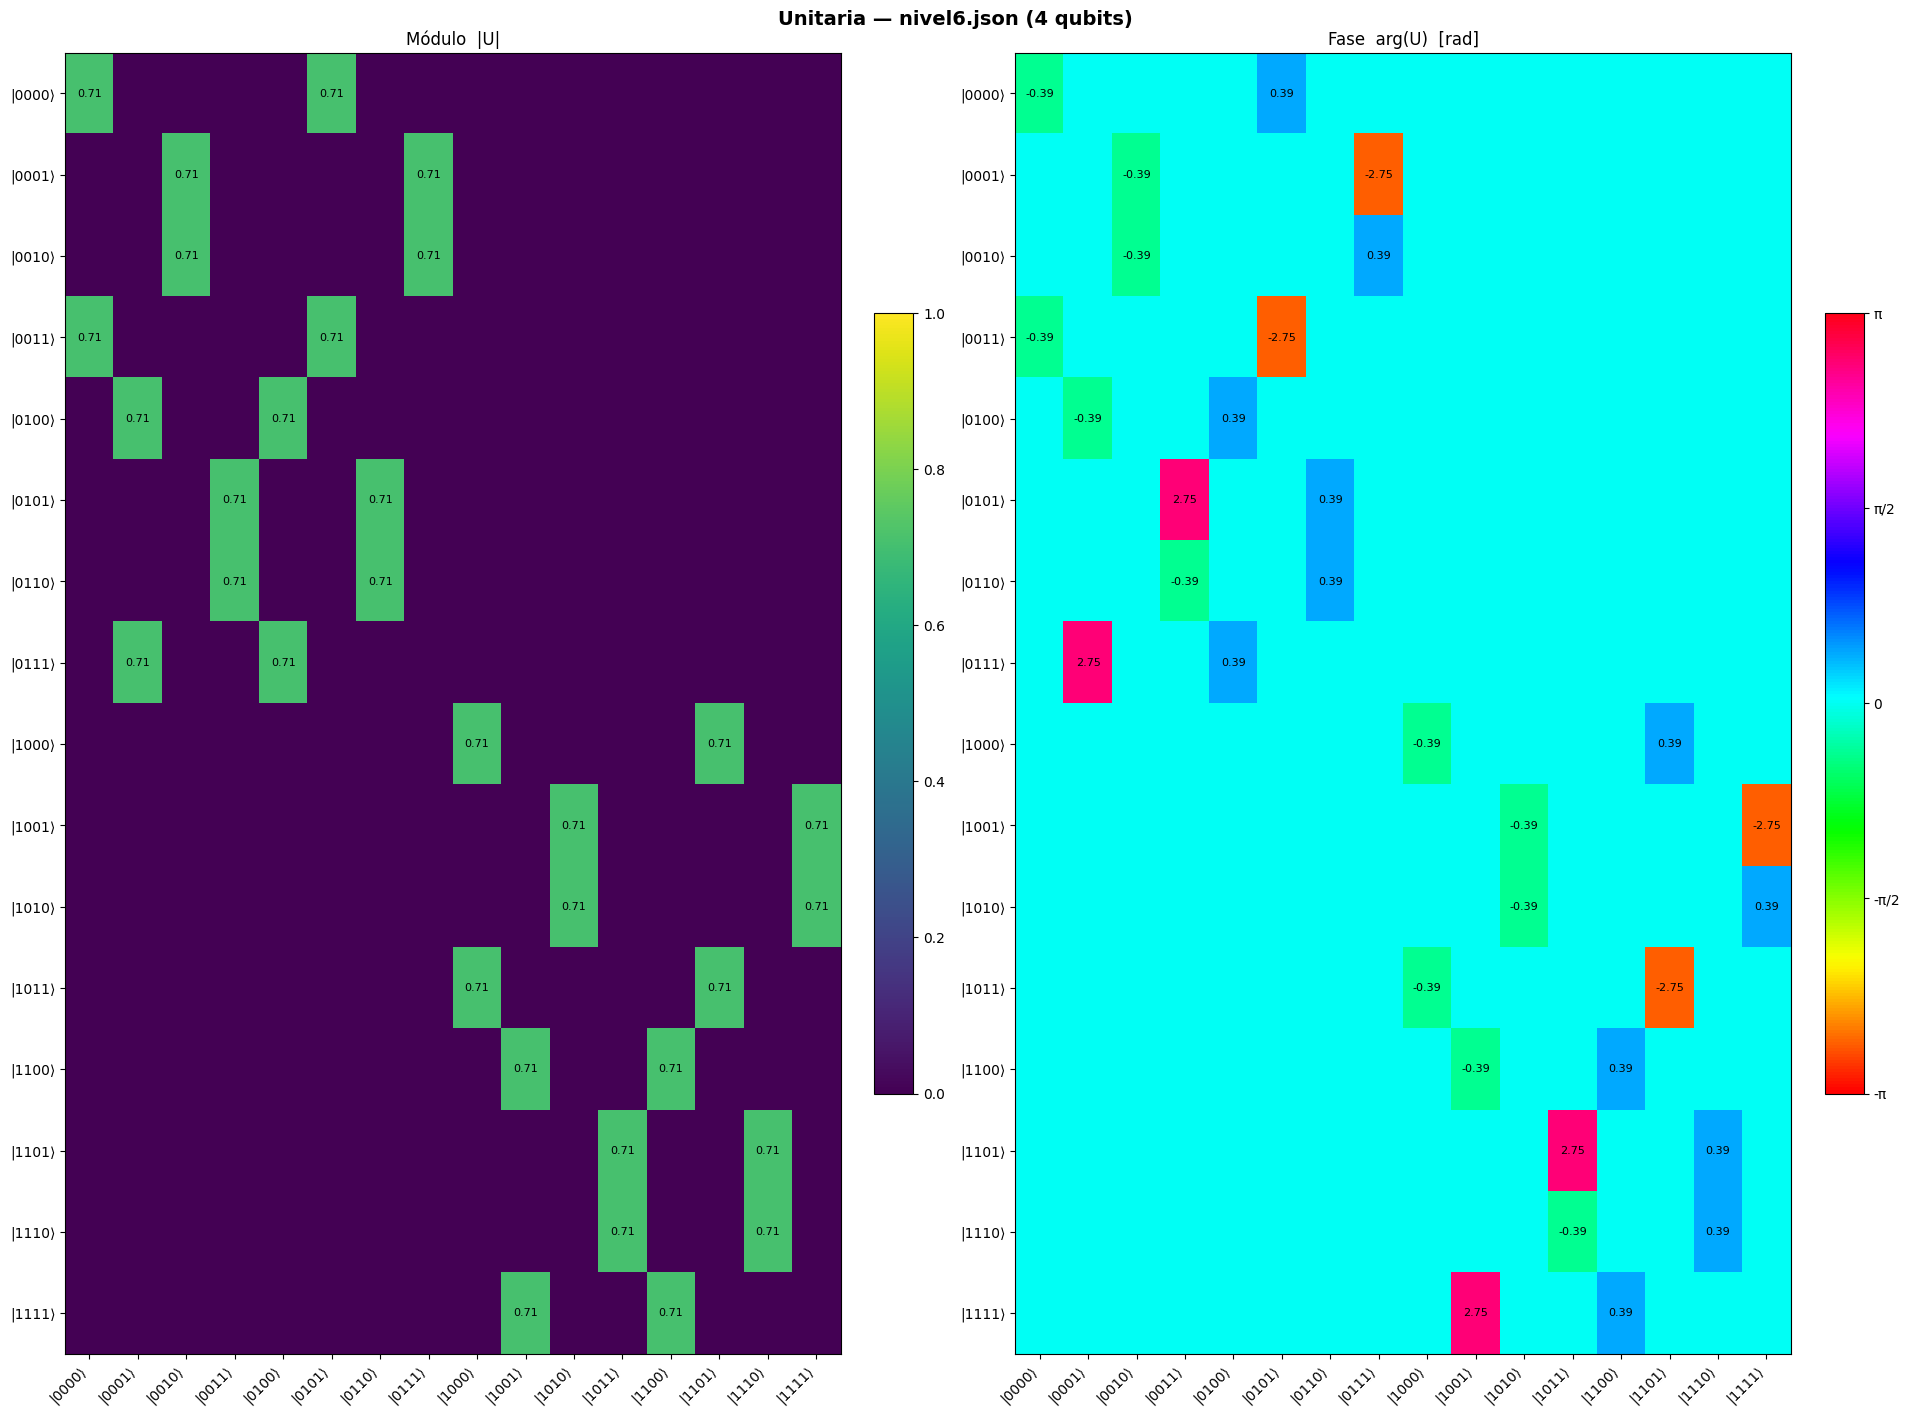

In [41]:
plot_unitary(U1, title="Unitaria — nivel6.json (4 qubits)")

---
## 🛠️ 6. Utilidades extra

### `are_equivalent(qc_a, qc_b)`
Compara dos circuitos por su unitaria (útil para verificar optimizaciones).

### `unitary_to_json(U, path)`
Exporta la matriz a JSON (real e imaginaria separadas).

In [27]:
def are_equivalent(qc_a: QuantumCircuit, qc_b: QuantumCircuit, atol: float = 1e-8) -> bool:
    """
    Devuelve True si los dos circuitos implementan la misma unitaria
    (salvo fase global).
    """
    Ua = get_unitary(qc_a)
    Ub = get_unitary(qc_b)
    if Ua.shape != Ub.shape:
        return False
    # Eliminar fase global: comparar Ua con e^{iθ}·Ub
    # Si son equivalentes salvo fase, Ua†·Ub es proporcional a la identidad
    product = Ua.conj().T @ Ub
    diag    = np.diag(product)
    if not np.allclose(np.abs(diag), 1.0, atol=atol):
        return False
    phase = diag[0]
    return np.allclose(product, phase * np.eye(Ua.shape[0]), atol=atol)


def unitary_to_json(U: np.ndarray, path: str | Path) -> Path:
    """
    Exporta la matriz unitaria a JSON alternando partes real e imaginaria.

    Formato::

        [
          [[a11_real, a11_imag], [a12_real, a12_imag]],
          [[a21_real, a21_imag], [a22_real, a22_imag]]
        ]
    """
    output = Path(path)
    payload = np.stack((np.round(U.real, 10), np.round(U.imag, 10)), axis=-1).tolist()
    output.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return output
print("✅ Utilidades definidas")

✅ Utilidades definidas


In [28]:
def are_equivalent(qc_a: QuantumCircuit, qc_b: QuantumCircuit, atol: float = 1e-8) -> bool:
    """
    Devuelve True si los dos circuitos implementan la misma unitaria
    (salvo fase global).
    """
    Ua = get_unitary(qc_a)
    Ub = get_unitary(qc_b)
    if Ua.shape != Ub.shape:
        return False
    # Eliminar fase global: comparar Ua con e^{iθ}·Ub
    # Si son equivalentes salvo fase, Ua†·Ub es proporcional a la identidad
    product = Ua.conj().T @ Ub
    diag    = np.diag(product)
    if not np.allclose(np.abs(diag), 1.0, atol=atol):
        return False
    phase = diag[0]
    return np.allclose(product, phase * np.eye(Ua.shape[0]), atol=atol)


def unitary_to_json(U: np.ndarray, path: str | Path) -> Path:
    """
    Exporta la matriz unitaria a JSON alternando partes real e imaginaria.

    Formato::

        [
          [[a11_real, a11_imag], [a12_real, a12_imag]],
          [[a21_real, a21_imag], [a22_real, a22_imag]]
        ]
    """
    output = Path(path)
    payload = np.stack((np.round(U.real, 10), np.round(U.imag, 10)), axis=-1).tolist()
    output.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return output
print("✅ Utilidades definidas")

✅ Utilidades definidas


In [29]:
import math
import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import UnitaryGate

def decompose_into_two_level(V_in: np.ndarray):
    """
    Descompone una matriz unitaria NxN en una serie de matrices unitarias de dos niveles.
    Retorna una lista de tuplas: (index_i, index_j, matriz_2x2)
    que representan el producto T_1^dag * T_2^dag * ... * D = V.
    """
    V = np.array(V_in, dtype=complex)
    N = V.shape[0]
    two_level_matrices = []
    
    # Eliminación Gaussiana para matrices unitarias
    for i in range(N - 1):
        for j in range(i + 1, N):
            if np.abs(V[j, i]) < 1e-10:
                continue
                
            a = V[i, i]
            b = V[j, i]
            r = np.sqrt(np.abs(a)**2 + np.abs(b)**2)
            
            # Construir la unitaria de 2x2 para hacer 0 el elemento V[j, i]
            u = np.zeros((2, 2), dtype=complex)
            u[0, 0] = np.conj(a) / r
            u[0, 1] = np.conj(b) / r
            u[1, 0] = -b / r
            u[1, 1] = a / r
            
            # Aplicar V' = T * V
            row_i = u[0, 0] * V[i, :] + u[0, 1] * V[j, :]
            row_j = u[1, 0] * V[i, :] + u[1, 1] * V[j, :]
            V[i, :] = row_i
            V[j, :] = row_j
            
            # Guardamos la inversa (T^dag) ya que V = T_1^dag ... D
            u_dag = np.conj(u).T
            two_level_matrices.append((i, j, u_dag))
            
    # La matriz V ahora es diagonal. Convertimos estas fases a matrices de 2 niveles.
    phase_matrices = []
    for i in range(N):
        phase = V[i, i]
        if np.abs(phase - 1.0) > 1e-10:
            j = (i + 1) % N
            u_phase = np.array([[phase, 0], [0, 1]], dtype=complex)
            phase_matrices.append((i, j, u_phase))
            
    # El orden de aplicación en el circuito es: fases primero, luego las T en orden inverso a su cálculo
    return phase_matrices + list(reversed(two_level_matrices))

def gray_code_path(s: int, t: int, num_qubits: int):
    """Genera la ruta de código Gray (diferencia de 1 bit por paso) entre s y t."""
    path = [s]
    diff = s ^ t
    current = s
    for i in range(num_qubits):
        if (diff >> i) & 1:
            current ^= (1 << i)
            path.append(current)
    return path

def apply_mcx_for_swap(qc: QuantumCircuit, g_state: int, target_bit: int, num_qubits: int):
    """Aplica una compuerta MCX para intercambiar g_k y g_{k+1}."""
    controls = []
    x_flips = []
    for i in range(num_qubits):
        if i == target_bit:
            continue
        controls.append(i)
        bit_val = (g_state >> i) & 1
        if bit_val == 0:
            x_flips.append(i)
            
    if x_flips:
        qc.x(x_flips)
        
    if controls:
        qc.mcx(controls, target_bit)
    else:
        qc.x(target_bit)
        
    if x_flips:
        qc.x(x_flips)

def apply_controlled_u(qc: QuantumCircuit, u: np.ndarray, g_m_minus_1: int, g_m: int, target_bit: int, num_qubits: int):
    """Aplica C^{n-1}(U) en el subespacio definido por g_{m-1} y g_m."""
    s_bit = (g_m_minus_1 >> target_bit) & 1
    t_bit = (g_m >> target_bit) & 1
    
    # Si la base está invertida (g_{m-1} tiene 1 y g_m tiene 0), conjugamos u con X
    if s_bit == 1 and t_bit == 0:
        X = np.array([[0, 1], [1, 0]])
        u = X @ u @ X

    controls = []
    x_flips = []
    # Los controles están dados por g_m (o g_m_minus_1, coinciden en todo salvo target_bit)
    for i in range(num_qubits):
        if i == target_bit:
            continue
        controls.append(i)
        bit_val = (g_m >> i) & 1
        if bit_val == 0:
            x_flips.append(i)
            
    if x_flips:
        qc.x(x_flips)
        
    if controls:
        c_u = UnitaryGate(u).control(len(controls))
        qc.append(c_u, controls + [target_bit])
    else:
        qc.append(UnitaryGate(u), [target_bit])
        
    if x_flips:
        qc.x(x_flips)

def decompose_unitary_to_mc(V_in: np.ndarray) -> QuantumCircuit:
    """
    Función principal: toma una unitaria arbitraria y devuelve un QuantumCircuit 
    compuesto por Toffolis generalizadas y compuertas C^{n-1}(U).
    """
    dim = V_in.shape[0]
    num_qubits = int(math.log2(dim))
    qc = QuantumCircuit(num_qubits)
    
    two_level_decomp = decompose_into_two_level(V_in)
    
    for s, t, u in two_level_decomp:
        if s == t:
            continue # Subespacio trivial
            
        path = gray_code_path(s, t, num_qubits)
        m = len(path)
        
        # 1. Forward swaps (Toffolis generalizadas)
        for k in range(m - 2):
            g_k = path[k]
            g_k_plus_1 = path[k+1]
            # Bit que difiere
            target_bit = int(math.log2(g_k ^ g_k_plus_1))
            apply_mcx_for_swap(qc, g_k, target_bit, num_qubits)
            
        # 2. Aplicar C^{n-1}(U)
        g_m_minus_1 = path[-2]
        g_m = path[-1]
        target_bit = int(math.log2(g_m_minus_1 ^ g_m))
        apply_controlled_u(qc, u, g_m_minus_1, g_m, target_bit, num_qubits)
        
        # 3. Reverse swaps (Uncomputation)
        for k in reversed(range(m - 2)):
            g_k = path[k]
            g_k_plus_1 = path[k+1]
            target_bit = int(math.log2(g_k ^ g_k_plus_1))
            apply_mcx_for_swap(qc, g_k, target_bit, num_qubits)
            
    return qc



In [30]:
nivel2=decompose_unitary_to_mc(U1)
nivel2.draw()

┌───┐┌───┐                ┌───┐     ┌───┐          ┌─────────┐     »
q_0: ─────┤ X ├┤ X ├──────────■─────┤ X ├─────┤ X ├──────────┤ Unitary ├─────»
     ┌───┐└─┬─┘├───┤     ┌────┴────┐├───┤     └─┬─┘┌───┐     └────┬────┘     »
q_1: ┤ X ├──■──┤ X ├─────┤ Unitary ├┤ X ├───────■──┤ X ├──────────■──────────»
     └───┘  │  └───┘     └────┬────┘└───┘       │  └───┘          │          »
q_2: ───────■─────────────────■─────────────────■─────────────────■──────────»
     ┌───┐  │  ┌───┐┌───┐     │     ┌───┐┌───┐  │  ┌───┐┌───┐     │     ┌───┐»
q_3: ┤ X ├──■──┤ X ├┤ X ├─────■─────┤ X ├┤ X ├──■──┤ X ├┤ X ├─────■─────┤ X ├»
     └───┘     └───┘└───┘           └───┘└───┘     └───┘└───┘           └───┘»
«          ┌───┐┌───┐          ┌───┐┌───┐     ┌───┐┌───┐           ┌───┐┌───┐»
«q_0: ─────┤ X ├┤ X ├───────■──┤ X ├┤ X ├──■──┤ X ├┤ X ├─────■─────┤ X ├┤ X ├»
«          └─┬─┘└───┘     ┌─┴─┐├───┤└───┘  │  ├───┤├───┤     │     ├───┤├───┤»
«q_1: ───────■────────────┤ X ├┤ X ├───────■──┤ X ├┤ X ├─────■─────┤ X ├┤ X ├»
«            │            └─┬─┘└───┘     ┌─┴─┐├───┤└───┘     │     ├───┤└───┘»
«q_2: ───────■──────────────■────────────┤ X ├┤ X ├──────────■─────┤ X ├─────»
«     ┌───┐  │  ┌───┐┌───┐  │  ┌───┐┌───┐└─┬─┘├───┤     ┌────┴────┐├───┤     »
«q_3: ┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├─────┤ Unitary ├┤ X ├─────»
«     └───┘     └───┘└───┘     └───┘└───┘     └───┘     └─────────┘└───┘     »
«          ┌───┐┌───┐     ┌───┐     ┌───┐     ┌───┐┌───┐           ┌───┐┌───┐»
«q_0: ──■──┤ X ├┤ X ├──■──┤ X ├─────┤ X ├─────┤ X ├┤ X ├─────■─────┤ X ├┤ X ├»
«       │  ├───┤└───┘┌─┴─┐└───┘     └─┬─┘┌───┐└─┬─┘├───┤┌────┴────┐├───┤└─┬─┘»
«q_1: ──■──┤ X ├─────┤ X ├────────────■──┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■──»
«     ┌─┴─┐└───┘     └─┬─┘            │  └───┘  │  └───┘└────┬────┘└───┘  │  »
«q_2: ┤ X ├────────────■──────────────■─────────■────────────■────────────■──»
«     └─┬─┘┌───┐┌───┐  │  ┌───┐┌───┐  │  ┌───┐  │            │            │  »
«q_3: ──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├──■────────────■────────────■──»
«          └───┘└───┘     └───┘└───┘     └───┘                               »
«          ┌─────────┐┌───┐┌───┐     ┌───┐┌───┐     ┌───┐┌───┐           ┌───┐»
«q_0: ─────┤ Unitary ├┤ X ├┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├─────■─────┤ X ├»
«     ┌───┐└────┬────┘└─┬─┘└───┘┌─┴─┐├───┤└───┘  │  ├───┤├───┤     │     ├───┤»
«q_1: ┤ X ├─────■───────■───────┤ X ├┤ X ├───────■──┤ X ├┤ X ├─────■─────┤ X ├»
«     └───┘     │       │       └─┬─┘└───┘     ┌─┴─┐├───┤└───┘     │     ├───┤»
«q_2: ──────────■───────■─────────■────────────┤ X ├┤ X ├──────────■─────┤ X ├»
«               │       │         │            └─┬─┘└───┘     ┌────┴────┐└───┘»
«q_3: ──────────■───────■─────────■──────────────■────────────┤ Unitary ├─────»
«                                                             └─────────┘     »
«     ┌───┐     ┌───┐┌───┐     ┌───┐┌───┐     ┌───┐                     ┌───┐»
«q_0: ┤ X ├──■──┤ X ├┤ X ├──■──┤ X ├┤ X ├─────┤ X ├──────────■──────────┤ X ├»
«     ├───┤  │  ├───┤└───┘┌─┴─┐└───┘└─┬─┘┌───┐└─┬─┘┌───┐┌────┴────┐┌───┐└─┬─┘»
«q_1: ┤ X ├──■──┤ X ├─────┤ X ├───────■──┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■──»
«     └───┘┌─┴─┐└───┘     └─┬─┘       │  └───┘  │  └───┘└────┬────┘└───┘  │  »
«q_2: ─────┤ X ├────────────■─────────■─────────■────────────■────────────■──»
«          └─┬─┘            │         │         │            │            │  »
«q_3: ───────■──────────────■─────────■─────────■────────────■────────────■──»
«                                                                            »
«          ┌───┐┌───┐           ┌───┐┌───┐                                    »
«q_0: ─────┤ X ├┤ X ├─────■─────┤ X ├┤ X ├────────────■────────────■──────────»
«     ┌───┐└─┬─┘└───┘     │     └───┘└─┬─┘          ┌─┴─┐┌───┐     │     ┌───┐»
«q_1: ┤ X ├──■────────────■────────────■────────────┤ X ├┤ X ├─────■─────┤ X ├»
«     ├───┤  │  ┌───┐┌────┴────┐┌───┐  │  ┌───┐┌───┐└─┬─┘├───┤┌────┴────┐├───┤»
«q_2: ┤ X ├──■──┤ X ├┤ Unitary ├┤ X ├──■──┤ X 

In [34]:
U1

array([[ 0.65328123-0.27059865j,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.65328123+0.27059865j,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.        +0.j        ,
         0.65328123-0.27059865j,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        , -0.65328123-0.27059865j,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.        +0.j        ,  0.        +0.j        ,
         0.6

In [39]:
U2 = get_unitary(nivel2)
U2 = np.round(U2, 8)
U2

array([[ 0.65328123-0.27059865j,  0.        -0.j        ,
        -0.        +0.j        ,  0.        -0.j        ,
        -0.        +0.j        ,  0.65328123+0.27059865j,
         0.        +0.j        , -0.        -0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.        +0.j        , -0.        +0.j        ,
         0.65328123-0.27059865j, -0.        +0.j        ,
        -0.        -0.j        , -0.        -0.j        ,
         0.        +0.j        , -0.65328123-0.27059865j,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ,
         0.        +0.j        ,  0.        +0.j        ],
       [ 0.        +0.j        , -0.        -0.j        ,
         0.6

In [35]:
def compare_matrix(M1: np.ndarray, M2: np.ndarray) -> bool:
    # 1. Comprobar si tienen el mismo tamaño (mismos qubits)
    if M1.shape != M2.shape:
        print("Las matrices son de distinto tamaño (distinto número de qubits). ¡No pueden ser iguales!")
    else:
    # 2. Comprobar igualdad exacta
        exactamente_iguales = np.allclose(M1, M2, atol=1e-8)
        print(f"¿Son exactamente idénticas elemento por elemento?: {exactamente_iguales}")

        # 3. Comprobar igualdad SALVO por una fase global (lo más correcto en cuántica)
        if not exactamente_iguales:
            dim = M1.shape[0]
            # Multiplicamos la inversa conjugada de U6 por U2
            prod = np.conj(M1).T @ U2
            # Tomamos la fase del primer elemento que no sea cero
            phase = prod[0, 0]
        
            # Verificamos si el producto es igual a la matriz Identidad multiplicada por la fase
            eq_fase_global = np.allclose(prod, phase * np.eye(dim), atol=1e-8)
            print(f"¿Son equivalentes salvo una fase global?: {eq_fase_global}")

    return exactamente_iguales

In [33]:
compare_matrix(U1,U2)

¿Son exactamente idénticas elemento por elemento?: True


True